TITLE:
Smart Missing Person And Cyber Crime Analytics

Problem Statement

The increasing number of missing person and crime cases makes investigation difficult and time-consuming. Law enforcement agencies need a smart system that can analyze historical crime data, predict case outcomes, identify crime patterns, and recommend effective investigation strategies.

Objectives:

Predict whether a missing person will be found.

Analyze crime trends.

Identify crime hotspots.

Recommend search strategies.

Improve investigation efficiency.

DATA CLEANING AND PREPROCESSING

In [86]:
import pandas as pd
import numpy as np
 
df = pd.read_csv("Realistic_Crime_Investigation_Dataset_50000.csv")

print(df.shape)
print(df.info())
print(df.isnull().sum())

(51000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Case_ID                  51000 non-null  object 
 1   Crime_Type               47935 non-null  object 
 2   Age                      47911 non-null  float64
 3   Gender                   47977 non-null  object 
 4   Village                  47811 non-null  object 
 5   District                 47946 non-null  object 
 6   State                    47954 non-null  object 
 7   Location_Type            47926 non-null  object 
 8   Last_Seen_Time           47895 non-null  object 
 9   Weather                  47906 non-null  object 
 10  Evidence                 47974 non-null  object 
 11  Mobile_Signal_Available  47891 non-null  object 
 12  CCTV_Available           47998 non-null  object 
 13  Social_Media_Activity    47888 non-null  object 
 14  Distance_K

HANDLING MISSING VALUES

In [87]:
# Numerical Columns
num_cols = [
    'Age',
    'Distance_KM',
    'Search_Team_Size',
    'Investigation_Cost',
    'Search_Hours',
    'Recovery_Time_Hours',
    'Success_Probability'
]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


print(df.isnull().sum())

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\256558290.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\256558290.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

Case_ID                    0
Crime_Type                 0
Age                        0
Gender                     0
Village                    0
District                   0
State                      0
Location_Type              0
Last_Seen_Time             0
Weather                    0
Evidence                   0
Mobile_Signal_Available    0
CCTV_Available             0
Social_Media_Activity      0
Distance_KM                0
Risk_Level                 0
Search_Team_Size           0
Drone_Used                 0
Thermal_Camera_Used        0
Investigation_Cost         0
Search_Hours               0
Recovery_Time_Hours        0
Solution_Used              0
Success_Probability        0
Found                      0
dtype: int64


REMOVE DUPLICATES

In [88]:
print("before removing duplicates",df.duplicated().sum())

#after removing duplicates
df.drop_duplicates(inplace=True)
print("After removing duplicates",df.duplicated().sum())

before removing duplicates 1000
After removing duplicates 0


In [89]:
print(df)

          Case_ID      Crime_Type   Age  Gender     Village       District  \
0      CASE000001     Online Scam  39.0    Male  Peddapuram  Visakhapatnam   
1      CASE000002      Kidnapping  38.0  Female     Unknown  Visakhapatnam   
2      CASE000003        Phishing  38.0    Male    Samalkot          Kochi   
3      CASE000004     Online Scam  58.0    Male  Peddapuram      Bengaluru   
4      CASE000005        Phishing  35.0  Female    Samalkot      Bengaluru   
...           ...             ...   ...     ...         ...            ...   
49995  CASE049996        Phishing  30.0  Female  Rangampeta        Chennai   
49996  CASE049997     Cyber Fraud  28.0    Male    Samalkot          Kochi   
49997  CASE049998   Missing Adult  48.0    Male   Thondangi         Mumbai   
49998  CASE049999        Phishing  36.0  Female   Thondangi         Mumbai   
49999  CASE050000  Identity Theft  47.0    Male   Thondangi          Kochi   

                State Location_Type       Last_Seen_Time Weathe

In [90]:
df.dtypes

Case_ID                     object
Crime_Type                  object
Age                        float64
Gender                      object
Village                     object
District                    object
State                       object
Location_Type               object
Last_Seen_Time              object
Weather                     object
Evidence                    object
Mobile_Signal_Available     object
CCTV_Available              object
Social_Media_Activity       object
Distance_KM                float64
Risk_Level                  object
Search_Team_Size           float64
Drone_Used                  object
Thermal_Camera_Used         object
Investigation_Cost         float64
Search_Hours               float64
Recovery_Time_Hours        float64
Solution_Used               object
Success_Probability        float64
Found                       object
dtype: object

In [8]:
df.to_csv(r"C:\mini_project1\cleaned_dataset2.xlsx", index=False)

In [91]:
columns = df.columns
print(columns)

Index(['Case_ID', 'Crime_Type', 'Age', 'Gender', 'Village', 'District',
       'State', 'Location_Type', 'Last_Seen_Time', 'Weather', 'Evidence',
       'Mobile_Signal_Available', 'CCTV_Available', 'Social_Media_Activity',
       'Distance_KM', 'Risk_Level', 'Search_Team_Size', 'Drone_Used',
       'Thermal_Camera_Used', 'Investigation_Cost', 'Search_Hours',
       'Recovery_Time_Hours', 'Solution_Used', 'Success_Probability', 'Found'],
      dtype='object')


In [92]:
# ml_df = df.copy()
# for col in columns:
#     ml_df[col] = encoders[col].inverse_transform(
#         ml_df[col]
#     )
ml_df = df.copy()
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns = [
    'Crime_Type',
    'Gender',
    'Village',
    'District',
    'State',
    'Location_Type',
    'Last_Seen_Time',
    'Weather',
    'Evidence',
    'Mobile_Signal_Available',
    'CCTV_Available',
    'Social_Media_Activity',
    'Risk_Level',
    'Drone_Used',
    'Thermal_Camera_Used',
    'Found',
    'Solution_Used'
]

encoders = {}

for col in columns:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])

print(df.dtypes)


Case_ID                     object
Crime_Type                   int64
Age                        float64
Gender                       int64
Village                      int64
District                     int64
State                        int64
Location_Type                int64
Last_Seen_Time               int64
Weather                      int64
Evidence                     int64
Mobile_Signal_Available      int64
CCTV_Available               int64
Social_Media_Activity        int64
Distance_KM                float64
Risk_Level                   int64
Search_Team_Size           float64
Drone_Used                   int64
Thermal_Camera_Used          int64
Investigation_Cost         float64
Search_Hours               float64
Recovery_Time_Hours        float64
Solution_Used                int64
Success_Probability        float64
Found                        int64
dtype: object


EDA

In [93]:
#Total crime types
print(df['Crime_Type'].value_counts())

#Recovery Rate
print(df['Found'].value_counts())

Crime_Type
6    9762
4    6753
1    6741
2    6733
3    6701
0    6685
5    6625
Name: count, dtype: int64
Found
1    39490
0    10510
Name: count, dtype: int64


Data Visualization

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\3905213276.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Crime_Type', order=df['Crime_Type'].value_counts().index,palette='coolwarm')


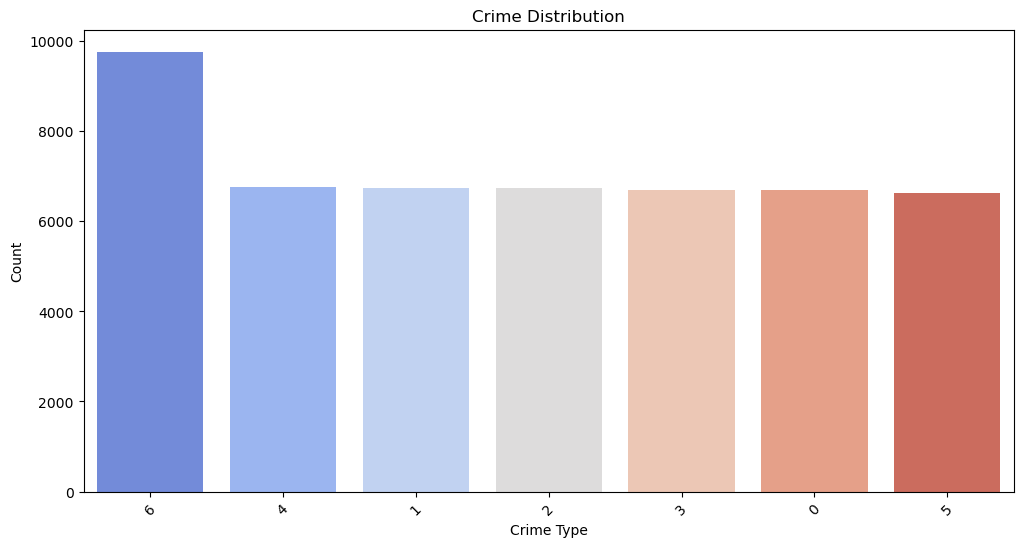

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\3905213276.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender',palette='Set2')


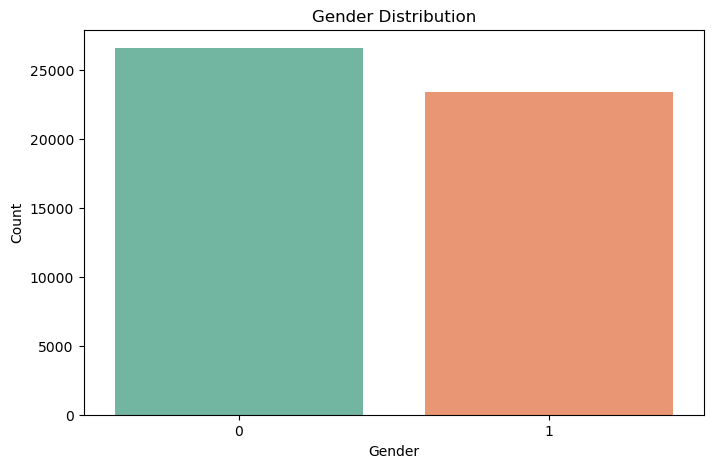

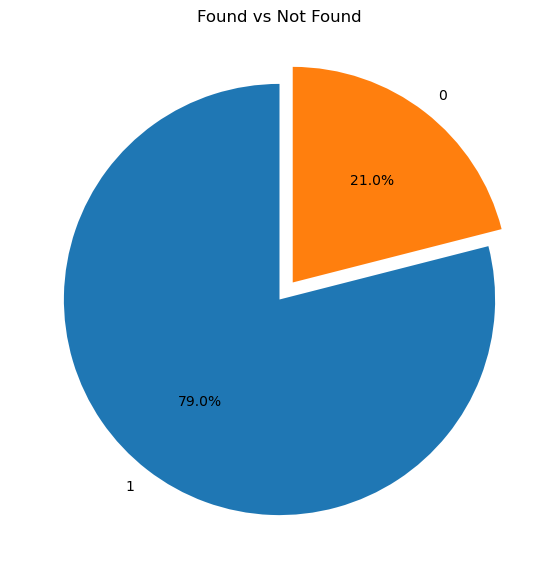

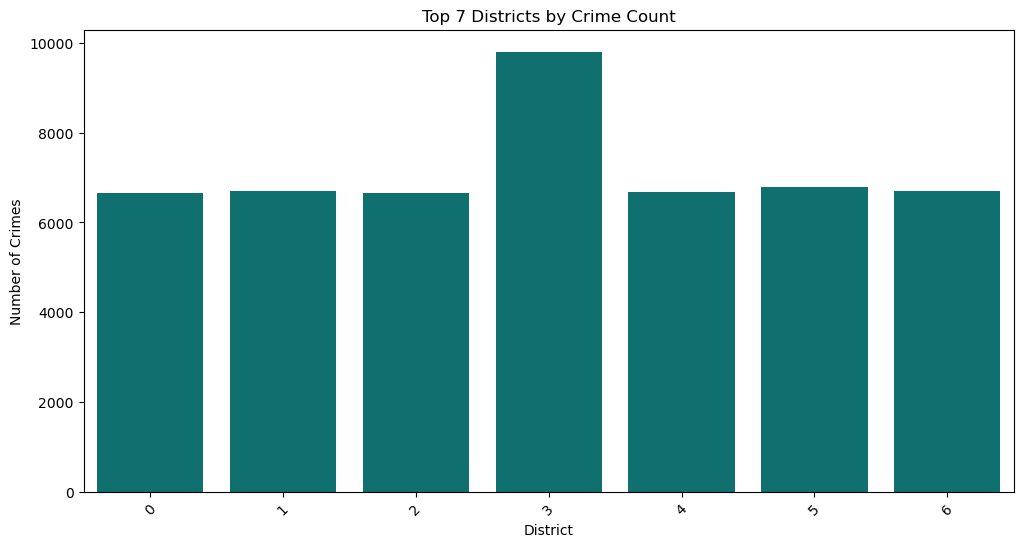

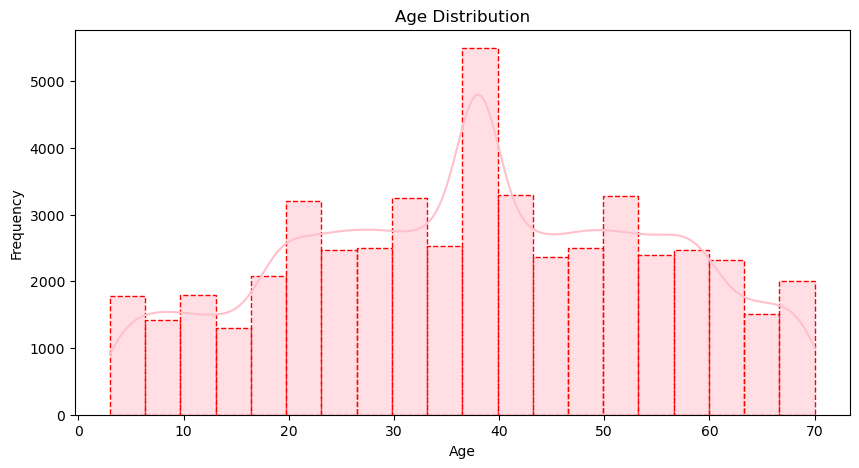

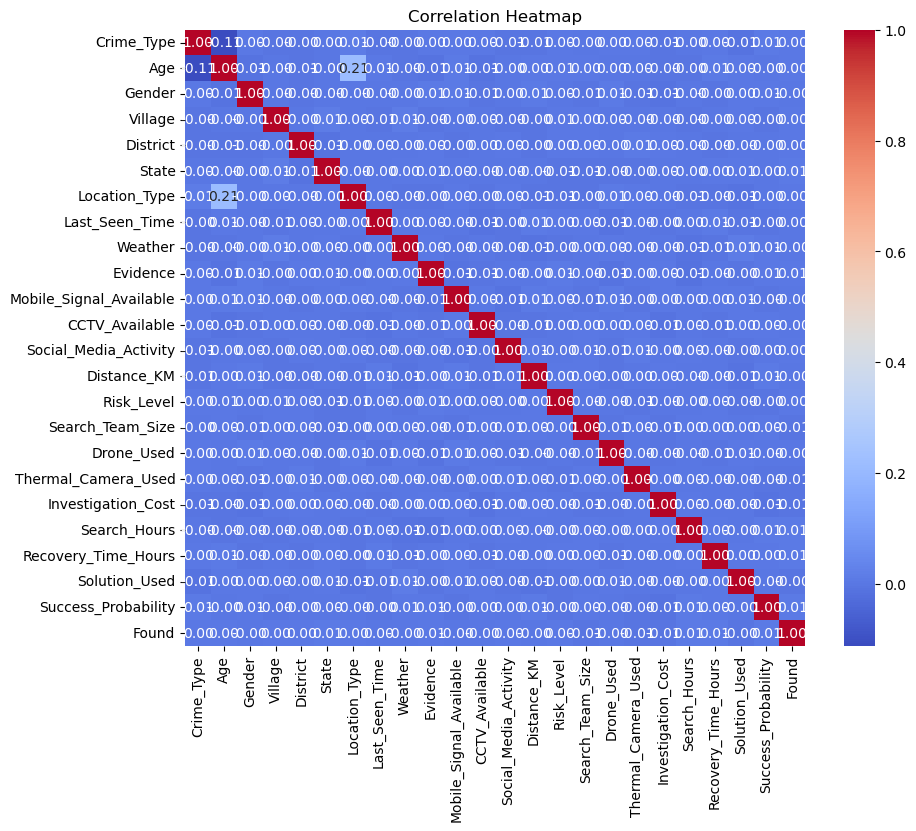

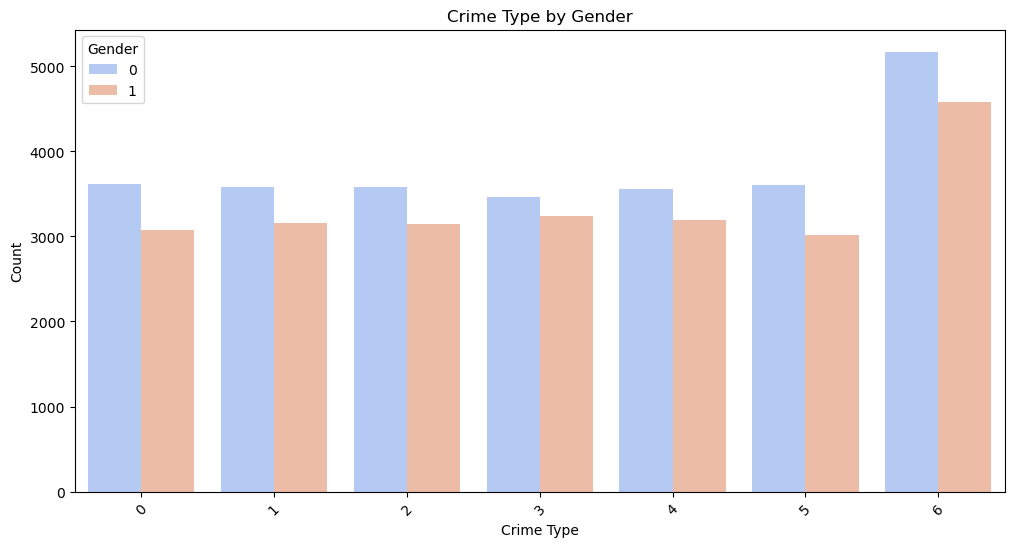

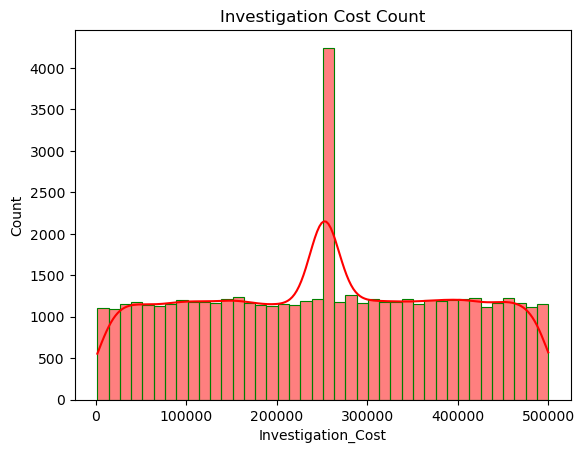

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

#Crime disrtbution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Crime_Type', order=df['Crime_Type'].value_counts().index,palette='coolwarm')
plt.title('Crime Distribution')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#Gender distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Gender',palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()
#FOund vs Not Found
found_counts = df['Found'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(found_counts,
        labels=found_counts.index,
        autopct='%1.1f%%',
        startangle=90,explode=[0,0.1])

plt.title('Found vs Not Found')
plt.show()

#Crime by district
district_counts = df['District'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=district_counts.index,
            y=district_counts.values,color = "teal")

plt.title('Top 7 Districts by Crime Count')
plt.xlabel('District')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.show()

#Age distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Age'],
             bins=20,
             kde=True,color = "pink",edgecolor = "red",linestyle = "dashed")

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

#Correlation Heatmap
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()
#Crime Type vs Gender
plt.figure(figsize=(12,6))
sns.countplot(data=df,
              x='Crime_Type',
              hue='Gender',palette='coolwarm')

plt.title('Crime Type by Gender')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#Cost distribution
plt.title('Investigation Cost Count')
sns.histplot(df['Investigation_Cost'],kde=True,color = "red",edgecolor = "green",linestyle = "solid")
plt.show()


4. Feature Engineering

In [95]:
df['Last_Seen_Time'] = pd.to_datetime(df['Last_Seen_Time'])

df['Hour'] = df['Last_Seen_Time'].dt.hour

df['Day'] = df['Last_Seen_Time'].dt.day

df['Month'] = df['Last_Seen_Time'].dt.month

df['Risk_Score'] = (
    df['Distance_KM']*0.4 +
    df['Search_Team_Size']*0.3 +
    df['Recovery_Time_Hours']*0.3
)
#New
df["Cost_Per_Hour"] = (
    df["Investigation_Cost"] /
    (df["Search_Hours"] + 1)
)

df["Search_Efficiency"] = (
    df["Search_Team_Size"] /
    (df["Distance_KM"] + 1)
)


df["Distance_Per_Team"] = (
    df["Distance_KM"] /
    (df["Search_Team_Size"] + 1)
)


print(df.head(10))

      Case_ID  Crime_Type   Age  Gender  Village  District  State  \
0  CASE000001           5  39.0       1        2         6      2   
1  CASE000002           2  38.0       0        6         6      2   
2  CASE000003           6  38.0       1        4         4      1   
3  CASE000004           5  58.0       1        2         0      0   
4  CASE000005           6  35.0       0        4         0      4   
5  CASE000006           5  38.0       0        1         3      3   
6  CASE000007           6  33.0       0        4         5      4   
7  CASE000008           5  69.0       0        1         5      5   
8  CASE000009           4  11.0       1        1         3      2   
9  CASE000010           2  53.0       0        5         6      1   

   Location_Type                Last_Seen_Time  Weather  ...  Solution_Used  \
0              4 1970-01-01 00:00:00.000013499        3  ...              1   
1              0 1970-01-01 00:00:00.000017642        4  ...              5   
2  

SQL ANALYSIS

Connecting Mysql to Python

In [96]:
import sys
!{sys.executable} -m pip install mysql-connector-python
import mysql.connector
conn = mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "awsm@mysql",
    database = "investigation"
)
cursor = conn.cursor()

In [97]:
import pandas as pd
query = "select * from clean"
df = pd.read_sql(query,conn)
print(df.head())
print(df.info())

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\2221917018.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


      Case_ID   Crime_Type  Age  Gender     Village       District  \
0  CASE000001  Online Scam   39    Male  Peddapuram  Visakhapatnam   
1  CASE000002   Kidnapping   38  Female     Unknown  Visakhapatnam   
2  CASE000003     Phishing   38    Male    Samalkot          Kochi   
3  CASE000004  Online Scam   58    Male  Peddapuram      Bengaluru   
4  CASE000005     Phishing   35  Female    Samalkot      Bengaluru   

            State Location_Type    Last_Seen_Time Weather  ... Risk_Level  \
0          Kerala        Online  13-09-2025 10:00     Hot  ...        Low   
1          Kerala          City  22-03-2026 20:00   Rainy  ...        Low   
2       Karnataka        Online  15-03-2026 14:00   Rainy  ...        Low   
3  Andhra Pradesh        Online  21-05-2024 22:00   Sunny  ...     Medium   
4      Tamil Nadu        Online  27-06-2025 02:00   Foggy  ...        Low   

  Search_Team_Size Drone_Used Thermal_Camera_Used  Investigation_Cost  \
0               47         No              

found and not found analysis

In [98]:
query = "SELECT Found,count(*) as total_cases from clean GROUP BY Found;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\2413951437.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


  Found  total_cases
0   Yes        39490
1    No        10510


Crime With Most Cases

In [99]:
query = "SELECT Crime_Type,COUNT(*) AS Total_Cases FROM clean GROUP BY Crime_Type ORDER BY Total_Cases DESC;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\3761521512.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


       Crime_Type  Total_Cases
0        Phishing         9762
1   Missing Child         6753
2  Identity Theft         6741
3      Kidnapping         6733
4   Missing Adult         6701
5     Cyber Fraud         6685
6     Online Scam         6625


The Time at most cases occur

In [100]:
query = "SELECT Last_Seen_Time, COUNT(*) AS Total_Cases FROM clean GROUP BY Last_Seen_Time ORDER BY Total_Cases DESC;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\3255482298.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


         Last_Seen_Time  Total_Cases
0      22-03-2026 20:00         3046
1      03-07-2025 19:00           10
2      19-11-2025 13:00           10
3      19-06-2024 16:00           10
4      01-01-2024 09:00            9
...                 ...          ...
18095  11-02-2024 20:00            1
18096  03-05-2025 21:00            1
18097  19-12-2024 19:00            1
18098  14-05-2024 16:00            1
18099  08-02-2024 11:00            1

[18100 rows x 2 columns]


Solutions That Are Used Most Often

In [101]:
query = "SELECT Solution_Used, COUNT(*) AS Usage_Count FROM clean GROUP BY Solution_Used ORDER BY Usage_Count DESC;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\3615345112.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


        Solution_Used  Usage_Count
0     Cyber Forensics        16402
1         IP Tracking        13410
2       Thermal Drone         6234
3       Ground Search         6141
4       CCTV Analysis         6113
5  Facial Recognition         1700


Most Successful solution

In [102]:
query = "SELECT Solution_Used, COUNT(*) AS Solved_cases FROM clean WHEre Found = 'Yes' GROUP BY Solution_Used ORDER BY Solved_cases DESC;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\811504290.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


        Solution_Used  Solved_cases
0     Cyber Forensics         12995
1         IP Tracking         10613
2       Thermal Drone          4918
3       CCTV Analysis          4863
4       Ground Search          4769
5  Facial Recognition          1332


Best Solution For Each Crime Type

In [103]:
query = "SELECT Crime_Type, Solution_Used, COUNT(*) AS Success_Count FROM clean WHERE Found = 'Yes' GROUP BY Crime_Type, Solution_Used ORDER BY Crime_Type, Success_Count DESC;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\1804395271.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


        Crime_Type       Solution_Used  Success_Count
0      Cyber Fraud     Cyber Forensics           2780
1      Cyber Fraud         IP Tracking           2470
2   Identity Theft     Cyber Forensics           2813
3   Identity Theft         IP Tracking           2535
4       Kidnapping       Thermal Drone           1728
5       Kidnapping       CCTV Analysis           1649
6       Kidnapping       Ground Search           1585
7       Kidnapping     Cyber Forensics            318
8    Missing Adult       Thermal Drone           1689
9    Missing Adult       CCTV Analysis           1670
10   Missing Adult       Ground Search           1648
11   Missing Adult     Cyber Forensics            322
12   Missing Child       Ground Search           1277
13   Missing Child       CCTV Analysis           1263
14   Missing Child  Facial Recognition           1262
15   Missing Child       Thermal Drone           1229
16   Missing Child     Cyber Forensics            281
17     Online Scam     Cyber

Avg Recovery Time

In [104]:
query = "SELECT Crime_Type, ROUND(AVG(Recovery_Time_Hours),2) AS Avg_Recovery_Time FROM clean WHERE Found='Yes' GROUP BY Crime_Type ORDER BY Avg_Recovery_Time DESC;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\1107152836.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


       Crime_Type  Avg_Recovery_Time
0  Identity Theft             121.70
1        Phishing             121.08
2   Missing Child             120.97
3     Cyber Fraud             120.39
4   Missing Adult             120.31
5      Kidnapping             120.11
6     Online Scam             119.49


Top 5 Villages With Most Cases

In [105]:
query = "SELECT village, COUNT(*) AS Total_cases FROM clean GROUP BY village ORDER BY Total_Cases DESC Limit 5;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\1121712470.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


      village  Total_cases
0    Samalkot         9890
1  Peddapuram         6762
2  Gollaprolu         6711
3   Anaparthi         6699
4   Thondangi         6676


Evidence Type That Solves Most Cases

In [106]:
query = "SELECT Evidence, COUNT(*) AS Solved_Cases FROM clean WHERE Found='Yes' GROUP BY Evidence ORDER BY Solved_Cases DESC;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\1193406507.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


        Evidence  Solved_Cases
0     IP Address          8519
1   Social Media          6279
2           CCTV          6227
3        Witness          6185
4   Call Records          6163
5  Mobile Signal          6117


Average Search Team Size by Solution

In [107]:
query = "SELECT Solution_Used, ROUND(AVG(Search_Team_Size),2) AS Avg_Team_Size FROM clean GROUP BY Solution_Used ORDER BY Avg_Team_Size DESC;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\144283719.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


        Solution_Used  Avg_Team_Size
0       CCTV Analysis         128.62
1         IP Tracking         127.97
2       Thermal Drone         127.53
3       Ground Search         127.20
4     Cyber Forensics         126.94
5  Facial Recognition         126.02


Average Investigation Cost by Crime Type

In [108]:
query = "SELECT Crime_Type,ROUND(AVG(Investigation_Cost),2) AS Avg_Cost FROM clean GROUP BY Crime_Type ORDER BY Avg_Cost DESC;"
res = pd.read_sql_query(query,conn)
print(res)

C:\Users\shaik\AppData\Local\Temp\ipykernel_27976\3848840451.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql_query(query,conn)


       Crime_Type   Avg_Cost
0      Kidnapping  256022.09
1   Missing Adult  252788.80
2   Missing Child  251937.28
3  Identity Theft  251929.70
4     Cyber Fraud  251910.95
5        Phishing  251278.91
6     Online Scam  249739.02


In [109]:
print(df.dtypes)

Case_ID                     object
Crime_Type                  object
Age                          int64
Gender                      object
Village                     object
District                    object
State                       object
Location_Type               object
Last_Seen_Time              object
Weather                     object
Evidence                    object
Mobile_Signal_Available     object
CCTV_Available              object
Social_Media_Activity       object
Distance_KM                  int64
Risk_Level                  object
Search_Team_Size             int64
Drone_Used                  object
Thermal_Camera_Used         object
Investigation_Cost           int64
Search_Hours                 int64
Recovery_Time_Hours          int64
Solution_Used               object
Success_Probability        float64
Found                       object
dtype: object


In [110]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns = [
    'Crime_Type',
    'Gender',
    'Village',
    'District',
    'State',
    'Location_Type',
    'Last_Seen_Time',
    'Weather',
    'Evidence',
    'Mobile_Signal_Available',
    'CCTV_Available',
    'Social_Media_Activity',
    'Risk_Level',
    'Drone_Used',
    'Thermal_Camera_Used',
    'Found',
    'Solution_Used'
]

encoders = {}

for col in columns:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])

print(df.dtypes)



Case_ID                     object
Crime_Type                   int64
Age                          int64
Gender                       int64
Village                      int64
District                     int64
State                        int64
Location_Type                int64
Last_Seen_Time               int64
Weather                      int64
Evidence                     int64
Mobile_Signal_Available      int64
CCTV_Available               int64
Social_Media_Activity        int64
Distance_KM                  int64
Risk_Level                   int64
Search_Team_Size             int64
Drone_Used                   int64
Thermal_Camera_Used          int64
Investigation_Cost           int64
Search_Hours                 int64
Recovery_Time_Hours          int64
Solution_Used                int64
Success_Probability        float64
Found                        int64
dtype: object


Statistical insights

In [111]:
print("Mean:",df['Age'].mean())
print("Median:",df['Age'].median())
print("Mode:",df['Age'].mode())
print("Stand dev:",df['Age'].std())
print("Recovery_Rate:",(df['Found']=="Yes").mean()*100)

Mean: 37.67388
Median: 38.0
Mode: 0    38
Name: Age, dtype: int64
Stand dev: 17.155822690581243
Recovery_Rate: 0.0


Train model

In [112]:
df.drop("Case_ID", axis=1, inplace=True)
X = df.drop("Found", axis=1)
y = df["Found"]

In [113]:
print(df.dtypes)

Crime_Type                   int64
Age                          int64
Gender                       int64
Village                      int64
District                     int64
State                        int64
Location_Type                int64
Last_Seen_Time               int64
Weather                      int64
Evidence                     int64
Mobile_Signal_Available      int64
CCTV_Available               int64
Social_Media_Activity        int64
Distance_KM                  int64
Risk_Level                   int64
Search_Team_Size             int64
Drone_Used                   int64
Thermal_Camera_Used          int64
Investigation_Cost           int64
Search_Hours                 int64
Recovery_Time_Hours          int64
Solution_Used                int64
Success_Probability        float64
Found                        int64
dtype: object


Train Test Split


In [114]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Random forest

In [115]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train,y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [119]:
X_train

,Crime_Type,Age,Gender,Village,District,State,Location_Type,Last_Seen_Time,Weather,Evidence,...,Distance_KM,Risk_Level,Search_Team_Size,Drone_Used,Thermal_Camera_Used,Investigation_Cost,Search_Hours,Recovery_Time_Hours,Solution_Used,Success_Probability
4613,6,37,1,1,3,5,1,14568,2,0,...,42,2,118,0,1,252935,60,88,5,61.76
23105,3,24,0,1,1,4,0,1049,4,4,...,51,2,246,0,0,334101,97,120,0,74.18
22510,6,40,0,4,6,0,4,15689,0,0,...,4,1,43,0,1,291689,117,127,4,88.94
31867,3,59,0,6,5,2,0,3632,4,5,...,6,1,39,1,1,15530,107,124,0,93.21
22996,5,22,1,3,2,1,4,9498,2,5,...,67,1,139,0,0,252165,37,11,4,60.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1557,3,55,1,3,6,5,2,8801,4,4,...,27,1,35,0,0,182132,68,136,3,85.62
11369,1,46,0,0,3,1,4,2889,0,2,...,98,1,237,1,1,230243,30,23,1,72.91
6029,1,19,0,6,0,4,4,5635,1,3,...,48,0,130,1,0,338881,90,238,4,78.89
17084,2,45,0,5,5,5,2,7172,3,4,...,21,1,191,1,0,69002,54,174,5,53.64


In [120]:
X_test

,Crime_Type,Age,Gender,Village,District,State,Location_Type,Last_Seen_Time,Weather,Evidence,...,Distance_KM,Risk_Level,Search_Team_Size,Drone_Used,Thermal_Camera_Used,Investigation_Cost,Search_Hours,Recovery_Time_Hours,Solution_Used,Success_Probability
17988,4,9,1,4,0,4,5,17732,0,0,...,82,2,143,1,0,100589,63,212,2,77.41
2461,4,7,1,1,6,1,1,1737,1,1,...,32,1,205,1,0,284844,87,120,0,77.74
15428,6,50,1,2,3,5,4,11540,1,4,...,70,1,57,1,0,82705,93,27,4,91.35
37240,0,67,1,6,2,2,4,9110,5,3,...,54,1,187,1,1,308413,29,97,1,74.18
8660,2,26,0,1,3,5,1,8223,3,5,...,17,2,48,0,1,224545,89,158,5,58.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27208,3,57,0,0,3,2,0,12790,4,4,...,47,0,179,1,1,100921,2,120,0,87.68
17511,0,42,0,1,5,2,4,1269,0,4,...,51,2,78,0,0,145993,73,125,1,56.77
27520,0,18,1,3,4,1,4,8379,5,2,...,71,0,127,1,1,74943,109,70,4,90.73
17195,6,55,1,3,1,2,4,637,5,4,...,29,1,152,0,1,185262,62,121,4,91.48


In [121]:
y_train

4613     1
23105    1
22510    1
31867    1
22996    1
        ..
1557     1
11369    0
6029     1
17084    0
8422     0
Name: Found, Length: 40000, dtype: int64

In [122]:
y_test

17988    1
2461     1
15428    1
37240    1
8660     1
        ..
27208    1
17511    0
27520    1
17195    1
15302    1
Name: Found, Length: 10000, dtype: int64

Testing

In [123]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    pred
)
print(pred)
print("Accuracy =",accuracy)

[1 1 1 ... 1 1 1]
Accuracy = 0.7898
